### Simulated Tempering Implementation


Simulated Tempering (ST) belongs to the tempering family together with Parallel Tempering (PT).

**Plan in this notebook**

1. Run an **SMC sampler** to build a tempering ladder $\{\lambda_t\}$ and estimates of intermediate normalizing constants $\{\log Z_t\}$.
2. Define the ST targets
   $$
   \pi_t(x)=\frac{1}{Z_t}\,\tilde\pi_{\lambda_t}(x),\qquad
   \tilde\pi_{\lambda}(x)=\pi_0(x)^{1-\lambda}\pi_1(x)^{\lambda}.
   $$
   With a uniform temperature prior, each ladder level is visited roughly equally often.
3. Transition $(t,x)\to(t',x')$ in two Metropolis–Hastings substeps:
   - **Explore:** $x'=x+\mathcal N(0,\sigma^2 I)$ at fixed $t$.
   - **Jump:** propose $t'\in\{t-1,t+1\}$ (boundary-aware proposal $q$), keep $x$ fixed.
4. Collect samples only when the chain is at the **cold** level $t=T$ ($\lambda_T=1$).

Compare later with SMC and Parallel Tempering on the same targets.


In [1]:
from pathlib import Path
import runpy

for _root in [Path.cwd(), *Path.cwd().parents]:
    _setup = _root / "setup_path.py"
    if _setup.is_file():
        runpy.run_path(str(_setup), run_name="__setup_path__")
        break

from dataclasses import dataclass

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import lax, random, vmap
from jax.scipy.stats import norm

from libs import SMC


### State and ST sampler

State is the pair `(t_idx, x)` where `t_idx` indexes the SMC ladder
`lambda_path[t_idx]` with matching `log_z_path[t_idx]`.


In [2]:

@dataclass
class TemperingState:
    """ST Markov state: ladder index + configuration."""
    t_idx: int
    x: jnp.ndarray


class SimulatedTempering:
    """Simulated Tempering on an SMC tempering ladder.

    Joint target (uniform temperature prior):
        pi(t, x) propto pi_t(x) = tilde_pi_{lambda_t}(x) / Z_t

    Moves
    -----
    explore : x' = x + N(0, step_size^2 I), MH at fixed t
    jump    : t' in {t-1, t+1} (boundary-aware proposal q), MH with
              density ratio * q(t|t') / q(t'|t)

    Sampling
    --------
    `run` draws many independent excursions in parallel via `vmap(run_excursion)`.
    """

    def __init__(
        self,
        smc: SMC,
        lambda_path,
        log_z_path,
        step_size: float = 0.1,
        seed: int = 0,
        dims: int = 1,
    ):
        self.smc = smc
        self.lambda_path = jnp.asarray(lambda_path, dtype=float)
        self.log_z_path = jnp.asarray(log_z_path, dtype=float)
        if self.lambda_path.shape != self.log_z_path.shape:
            raise ValueError("lambda_path and log_z_path must have the same length")
        if int(self.lambda_path.shape[0]) < 2:
            raise ValueError("need at least 2 ladder levels")
        self.n_levels = int(self.lambda_path.shape[0])
        self.t_cold = self.n_levels - 1
        self.t_hot = 0
        self.step_size = float(step_size)
        self.dims = int(dims)
        self._key = random.key(seed)

    def log_pi_t(self, t_idx, x):
        """log pi_t(x) = log tilde_pi_lambda(x) - log Z_t (JAX-indexable t_idx)."""
        lam = self.lambda_path[t_idx]
        log_z = self.log_z_path[t_idx]
        return self.smc.get_intermediate_logpdf(x, lam) - log_z

    def explore(self, t_idx, x, key):
        """RW-MH on x at fixed t. Returns (x_next, key)."""
        key, k_prop, k_u = random.split(key, 3)
        x_prop = x + self.step_size * random.normal(k_prop, shape=x.shape)
        log_alpha = self.log_pi_t(t_idx, x_prop) - self.log_pi_t(t_idx, x)
        accept = jnp.log(random.uniform(k_u)) < jnp.minimum(log_alpha, 0.0)
        x_next = jnp.where(accept, x_prop, x)
        return x_next, key

    def jump(self, t_idx, x, key):
        """Nearest-neighbor temperature MH jump. Returns (t_next, key)."""
        key, k_dir, k_u = random.split(key, 3)
        T = self.n_levels - 1
        u = random.uniform(k_dir)
        # boundary-aware proposal: only legal neighbor at ends
        t_prop = jnp.where(
            t_idx == 0,
            1,
            jnp.where(t_idx == T, T - 1, jnp.where(u < 0.5, t_idx - 1, t_idx + 1)),
        )
        q_fwd = jnp.where((t_idx == 0) | (t_idx == T), 1.0, 0.5)
        q_rev = jnp.where((t_prop == 0) | (t_prop == T), 1.0, 0.5)
        log_alpha = (
            self.log_pi_t(t_prop, x) - self.log_pi_t(t_idx, x)
            + jnp.log(q_rev) - jnp.log(q_fwd)
        )
        accept = jnp.log(random.uniform(k_u)) < jnp.minimum(log_alpha, 0.0)
        t_next = jnp.where(accept, t_prop, t_idx)
        return t_next, key

    def move(self, t_idx, x, key):
        """One ST transition: explore then jump. Returns (t_next, x_next, key)."""
        x, key = self.explore(t_idx, x, key)
        t_idx, key = self.jump(t_idx, x, key)
        return t_idx, x, key

    def run_excursion(self, x0, key, max_steps: int = 10_000):
        """Single excursion: start hot, stop on return to hot (or max_steps).

        Parameters
        ----------
        x0 : array (d,)
        key : PRNGKey
        max_steps : int

        Returns
        -------
        xs : (max_steps, d) states after each move (invalid after stop are repeats)
        ts : (max_steps,) temperature indices after each move
        cold_mask : (max_steps,) True where a live step visited t_cold
        n_steps : int number of moves until stop
        """
        x0 = jnp.asarray(x0, dtype=float).reshape((self.dims,))

        def body(carry):
            t_idx, x, key, step, left_hot, done = carry
            key, k_move = random.split(key)

            def do_move(_):
                t_new, x_new, key_new = self.move(t_idx, x, k_move)
                left_new = left_hot | (t_new != self.t_hot)
                # stop once we have left hot and returned
                done_new = left_new & (t_new == self.t_hot)
                return t_new, x_new, key_new, step + 1, left_new, done_new

            def stay(_):
                return t_idx, x, key, step, left_hot, done

            t_idx, x, key, step, left_hot, done = lax.cond(done, stay, do_move, operand=None)
            return t_idx, x, key, step, left_hot, done

        def cond(carry):
            _t, _x, _key, step, _left, done = carry
            return (step < max_steps) & (~done)

        init = (
            jnp.asarray(self.t_hot, dtype=jnp.int32),
            x0,
            key,
            jnp.asarray(0, dtype=jnp.int32),
            jnp.asarray(False),
            jnp.asarray(False),
        )
        # Use scan with early "done" freeze so outputs have fixed shape for vmap.
        def scan_step(carry, _):
            t_idx, x, key, step, left_hot, done = carry
            key, k_move = random.split(key)

            def do_move(_):
                t_new, x_new, key_new = self.move(t_idx, x, k_move)
                left_new = left_hot | (t_new != self.t_hot)
                done_new = left_new & (t_new == self.t_hot)
                return t_new, x_new, key_new, step + 1, left_new, done_new

            def stay(_):
                # still advance step counter for n_steps accounting only when not done
                return t_idx, x, key, step, left_hot, done

            new_carry = lax.cond(done, stay, do_move, operand=None)
            t_out, x_out, key_out, step_out, left_out, done_out = new_carry
            # cold visit only on a live (not-yet-done-before) move
            was_live = ~done
            cold = was_live & (t_out == self.t_cold)
            # if stay branch, step does not increase — fix stay to keep step for scan length
            return (t_out, x_out, key_out, step_out, left_out, done_out), (x_out, t_out, cold, was_live)

        (t_f, x_f, key_f, step_f, left_f, done_f), (xs, ts, cold_mask, live_mask) = lax.scan(
            scan_step, init, xs=None, length=max_steps
        )
        n_steps = jnp.sum(live_mask.astype(jnp.int32))
        return xs, ts, cold_mask, n_steps

    def run(
        self,
        n_excursions: int = 100,
        max_steps: int = 10_000,
        key=None,
    ):
        """Generate many (x0, key) pairs and vmap run_excursion over them.

        Returns
        -------
        cold_samples : (n_cold, d) pooled cold-level states across excursions
        n_steps : (n_excursions,) length of each excursion
        visit_counts : (n_levels,) visits while excursion was live
        """
        if key is None:
            self._key, key = random.split(self._key)

        key, k_x0, k_exc = random.split(key, 3)
        x0s = random.normal(k_x0, shape=(n_excursions, self.dims))
        keys = random.split(k_exc, n_excursions)

        xs, ts, cold_mask, n_steps = vmap(
            lambda x0, k: self.run_excursion(x0, k, max_steps=max_steps)
        )(x0s, keys)

        # xs: (E, S, d), cold_mask: (E, S), ts: (E, S)
        cold_samples = xs[cold_mask]
        visit_counts = jnp.bincount(ts.reshape(-1), length=self.n_levels)
        # visit_counts above counts frozen steps too; prefer live-only:
        # rebuild with live mask — run_excursion does not return live_mask.
        # Approximate: use cold + all ts weighted by whether step index < n_steps
        step_ids = jnp.arange(max_steps)[None, :]
        live = step_ids < n_steps[:, None]
        visit_counts = jnp.bincount(
            ts[live], length=self.n_levels
        )
        return cold_samples, n_steps, visit_counts


### Demo: 1-D Gaussian mixture

Target $\pi_1$ is a bimodal mixture; base $\pi_0$ is standard normal (SMC default prior).
We first build $\{\lambda_t,\log Z_t\}$ with SMC, then run ST on that ladder.


In [10]:
def mixture_logpdf(x):
    """log (0.5 N(-2,1) + 0.5 N(2,1)); supports scalar or SMC batch (n,) / (n,1)."""
    x = jnp.asarray(x)
    if x.ndim >= 1 and x.shape[-1] == 1:
        x = x[..., 0]
    return jnp.logaddexp(
        norm.logpdf(x, loc=-5.0, scale=1.0),
        norm.logpdf(x, loc=5.0, scale=1.0),
    ) - jnp.log(2.0)

Plot the pdf to show how it looks 

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_18397/4159264753.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


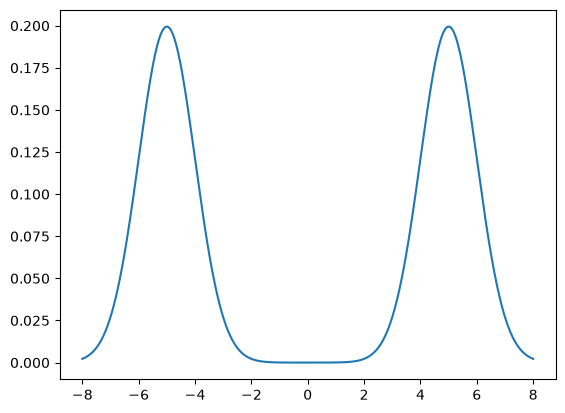

In [12]:
from matplotlib import pyplot as plt 
import numpy as np 

fig, ax = plt.subplots()
xx = np.linspace(-8, 8, 1000) 
yy = np.exp(mixture_logpdf(xx))

ax.plot(xx, yy)
fig.show()

In [13]:
# --- Stage 1: SMC ladder + Z_t ---
N_SMC = 10_000
smc = SMC(dims=1, target_dist_logpdf=mixture_logpdf, key=random.key(0))
smc.reset(no_samples=N_SMC)
lambda_path, log_z_path, tot_log_z = smc.build_intermediate_dists(
    mcmc_iters=10, verbose=True
)

print(f"ladder size = {len(lambda_path)}")
print(f"lambda_path = {[round(float(l), 4) for l in lambda_path]}")
print(f"log_z_path  = {[round(float(z), 4) for z in log_z_path]}")
print(f"tot log Z   = {float(tot_log_z):.4f}")


[SMC] step 0: lambda=0.0 -> 0.14501605927944183, diff_log_z=-1.2153830528259277
[SMC] step 1: lambda=0.14501605927944183 -> 0.27160051465034485, diff_log_z=-0.841221809387207
[SMC] step 2: lambda=0.27160051465034485 -> 0.38813239336013794, diff_log_z=-0.5147199630737305
[SMC] step 3: lambda=0.38813239336013794 -> 0.4999659061431885, diff_log_z=-0.214385986328125
[SMC] step 4: lambda=0.4999659061431885 -> 0.6081621050834656, diff_log_z=0.07899856567382812
[SMC] step 5: lambda=0.6081621050834656 -> 0.713352620601654, diff_log_z=0.34503650665283203
[SMC] step 6: lambda=0.713352620601654 -> 0.8226363062858582, diff_log_z=0.6545372009277344
[SMC] step 7: lambda=0.8226363062858582 -> 0.9293047785758972, diff_log_z=0.9293270111083984
[SMC] final step: lambda=0.9293047785758972 -> 1.0
ladder size = 10
lambda_path = [0.0, 0.145, 0.2716, 0.3881, 0.5, 0.6082, 0.7134, 0.8226, 0.9293, 1.0]
log_z_path  = [0.0, -1.2154, -2.0566, -2.5713, -2.7857, -2.7067, -2.3617, -1.7071, -0.7778, -0.0055]
tot log Z

In [14]:

# --- Stage 2: Simulated Tempering (batched excursions via vmap) ---
st = SimulatedTempering(
    smc=smc,
    lambda_path=lambda_path,
    log_z_path=log_z_path,
    step_size=0.05,
    seed=1,
    dims=1,
)

cold_samples, n_steps, visit_counts = st.run(
    n_excursions=500_000,
    max_steps=2_000,
    key=random.key(1),
)

print(f"cold samples pooled: {cold_samples.shape[0]}")
print(f"excursion length mean/median: {float(n_steps.mean()):.1f} / {float(jnp.median(n_steps)):.1f}")
print(f"visit counts by level: {np.asarray(visit_counts).tolist()}")
print(f"visit fractions: {(np.asarray(visit_counts) / np.asarray(visit_counts).sum()).round(3).tolist()}")
print(f"lambda at levels: {[round(float(l), 3) for l in lambda_path]}")


cold samples pooled: 248475
excursion length mean/median: 11.9 / 5.0
visit counts by level: [1212012, 1015903, 831978, 671533, 545146, 454207, 386331, 326834, 277392, 248475]
visit fractions: [0.203, 0.17, 0.139, 0.112, 0.091, 0.076, 0.065, 0.055, 0.046, 0.042]
lambda at levels: [0.0, 0.145, 0.272, 0.388, 0.5, 0.608, 0.713, 0.823, 0.929, 1.0]


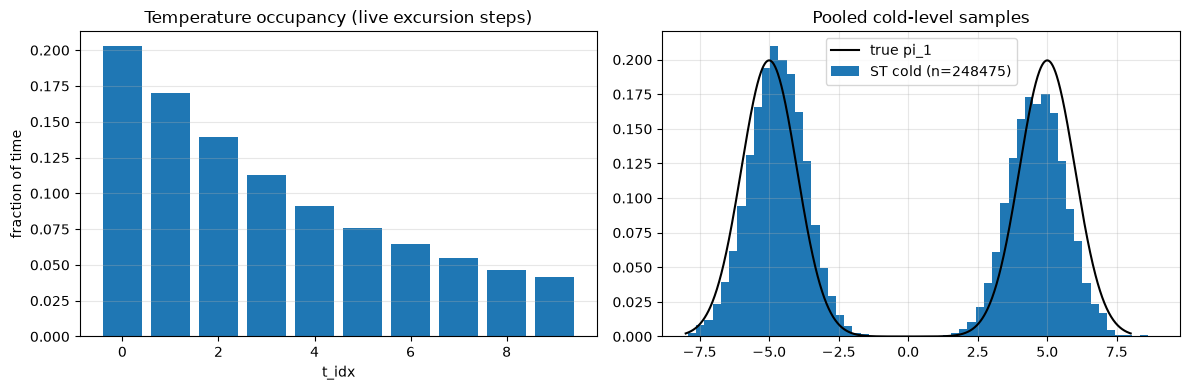

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# visit histogram
axes[0].bar(np.arange(st.n_levels), np.asarray(visit_counts) / np.asarray(visit_counts).sum())
axes[0].set_xlabel("t_idx")
axes[0].set_ylabel("fraction of time")
axes[0].set_title("Temperature occupancy (live excursion steps)")
axes[0].grid(axis="y", alpha=0.3)

# cold-level histogram vs true mixture density
xs = np.linspace(-8, 8, 1000)
ys = np.exp(mixture_logpdf(xs))
axes[1].plot(xs, ys, label="true pi_1", color="black")
if cold_samples.size:
    axes[1].hist(
        np.asarray(cold_samples).ravel(),
        bins="auto",
        density=True,
        #alpha=0.6,
        label=f"ST cold (n={cold_samples.shape[0]})",
    )
axes[1].set_title("Pooled cold-level samples")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Batched excursions via `vmap`

`run` draws `n_excursions` starting points `x0` and PRNG keys, then
`vmap`s `run_excursion(x0, key)` so independent hot→…→hot trajectories run in parallel.
Cold-level states from all excursions are pooled for the histogram.


In [16]:

# Excursions are already batched inside `st.run(...)` via vmap — no Python loop needed.
print(f"n_excursions: {int(n_steps.shape[0])}")
print(
    "excursion steps min/mean/max = "
    f"{int(n_steps.min())} / {float(n_steps.mean()):.1f} / {int(n_steps.max())}"
)
print(f"pooled cold samples: {int(cold_samples.shape[0])}")


n_excursions: 500000
excursion steps min/mean/max = 2 / 11.9 / 2000
pooled cold samples: 248475


### Notes

- Explore MH uses $\pi_t$ (equivalently $\tilde\pi_{\lambda_t}$; $Z_t$ cancels at fixed $t$).
- Jump MH uses $\pi_{t'}(x)/\pi_t(x)=[\tilde\pi_{\lambda_{t'}}/\tilde\pi_{\lambda_t}]\cdot[Z_t/Z_{t'}]$ times the boundary-aware $q$-ratio.
- Occupancy should be roughly flat across $t$ if SMC $\log Z_t$ estimates are accurate; large imbalance suggests refining the SMC ladder / particle count.
- Next: apply the same ST wrapper to Sudoku / Latin-square targets and compare against SMC and PT.
